Project overview: Help mining company find the best location for new oil wells by analyzing data from 3 regions and using bootstrapping to assess risks.  
Procedure:   
Model training and testing for each region, make predictions and calculate RMSE. Compare average predicted reserves across regions.   
Profit calculation. Calculate minimum reserves need to break even. Compare average reserves in each region.   
Create a function to select the top 200 wells by predicted reserves. Calculate total profit and test on each region.   
Risk analysis with bootstrapping. Calculate profit distribution, average profit, 95% confidence interval. Find risk of losses. Choose region with <2.5% loss risk and highest average profit. 

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from matplotlib import pyplot as plt
from numpy.random import RandomState
from sklearn.model_selection import train_test_split

In [2]:
#Load data
region_0_data = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/geo_data_0.csv')
region_1_data = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/geo_data_1.csv')
region_2_data = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/geo_data_2.csv')

In [3]:
#Key values 
BUDGET= 100000 #in thousands 
REVENUE_PER_BARREL = 4.5 
WELLS_TO_STUDY = 500
BEST_WELLS= 200

In [4]:
datasets = []

for i in range(3):
    data = pd.read_csv(f'https://practicum-content.s3.us-west-1.amazonaws.com/datasets/geo_data_{i}.csv')
    datasets.append(data)
    print(f"REGION {i} INFO:")
    print(data.info())
    print(data.head())
    print(data.describe())
    print()

region_0_data, region_1_data, region_2_data = datasets[0], datasets[1], datasets[2]

REGION 0 INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None
      id        f0        f1        f2     product
0  txEyH  0.705745 -0.497823  1.221170  105.280062
1  2acmU  1.334711 -0.340164  4.365080   73.037750
2  409Wp  1.022732  0.151990  1.419926   85.265647
3  iJLyR -0.032172  0.139033  2.978566  168.620776
4  Xdl7t  1.988431  0.155413  4.751769  154.036647
                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        0.500419       0.250143       2.502647      92.500000
std         0.871832       0.504433       

In [5]:
for i in range(3):
    duplicates = datasets[i].duplicated().any()
    print(f"Dataset {i} has duplicates: {duplicates}")

Dataset 0 has duplicates: False
Dataset 1 has duplicates: False
Dataset 2 has duplicates: False


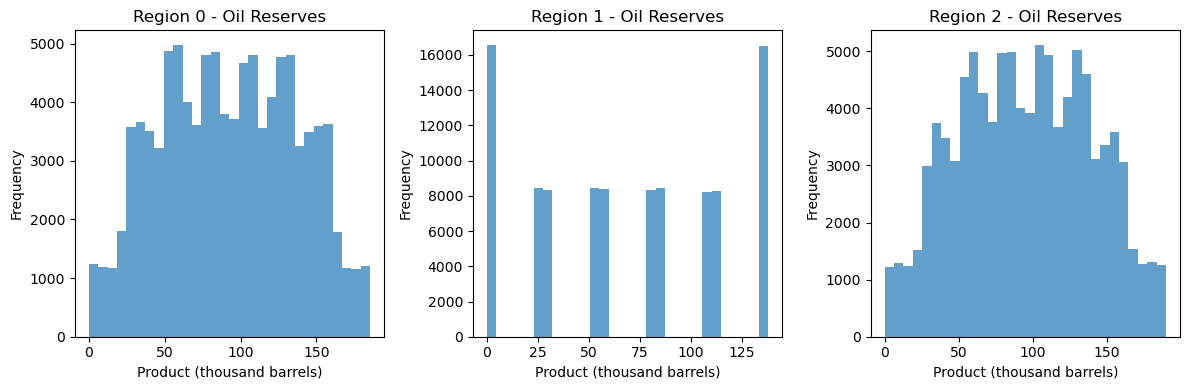

In [6]:
datasets = [region_0_data, region_1_data, region_2_data]

plt.figure(figsize=(12, 4))

for i in range(3):
    data = (datasets[i]) 
    plt.subplot(1, 3, i+1)
    plt.hist(data['product'], bins=30, alpha=0.7, label=f'Region {i}')
    plt.title(f'Region {i} - Oil Reserves')
    plt.xlabel('Product (thousand barrels)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


Each dataset has 100,000 rows, no missing values 
All datasets have the same columns: id, f0, f1, f2, product. 
All features are numerical (float64). Only id data is object.  

- Region 0 average product is 92.5 thousand barrels with oil reserves ranging from 0 to 185 thousand barrels. 
- Region 1 average product is 68.8 thousand barrels with oil reserves ranging from 0 to 138 thousand barrels. 
- Region 2 average product is 95.0 thousand barrels with oil reserves rangiing from 0 to 190 thousand barrels.
- Both region 0 and region 2 have the distrubution that appears to be roughly normal/bell-shaped. Region 1 has the most consistent, least variable reserves.  

The data does not have any duplicates. 


In [7]:
features = {}
targets = {}

for i in range(3):
    features[i] = datasets[i].drop(['id', 'product'], axis=1)
    targets[i] = datasets[i]['product']

features0, target0 = features[0], targets[0]
features1, target1 = features[1], targets[1]
features2, target2 = features[2], targets[2]

In [8]:
features_train0, features_valid0, target_train0, target_valid0 = train_test_split(
    features0, target0, test_size=.25, random_state=12345)

features_train1, features_valid1, target_train1, target_valid1 = train_test_split(
    features1, target1, test_size=.25, random_state=12345)

features_train2, features_valid2, target_train2, target_valid2 = train_test_split(
    features2, target2, test_size=.25, random_state=12345)

# Training 

In [9]:
def train_models_for_regions():
    print("MACHINE LEARNING MODEL TRAINING")
    print("=" * 50)
    regions_data = [
        (features_train0, features_valid0, target_train0, target_valid0),
        (features_train1, features_valid1, target_train1, target_valid1),
        (features_train2, features_valid2, target_train2, target_valid2)]
    
    model = LinearRegression()
    results = []
    
    for i, (feat_train, feat_valid, targ_train, targ_valid) in enumerate(regions_data):
        model.fit(feat_train, targ_train)
        predictions = model.predict(feat_valid)
        avg_predicted = predictions.mean()
        rmse = mean_squared_error(targ_valid, predictions)**0.5
        results.append({
            'region': i,
            'avg_predicted': avg_predicted,
            'rmse': rmse,
            'predictions': predictions})
        
        print(f"REGION {i} RESULTS:")
        print(f"Average predicted reserves is {avg_predicted:.2f} thousand barrels")
        print(f"RMSE: {rmse:.2f}")
        print()
    
    return results

model_results = train_models_for_regions()

MACHINE LEARNING MODEL TRAINING
REGION 0 RESULTS:
Average predicted reserves is 92.59 thousand barrels
RMSE: 37.58

REGION 1 RESULTS:
Average predicted reserves is 68.73 thousand barrels
RMSE: 0.89

REGION 2 RESULTS:
Average predicted reserves is 94.97 thousand barrels
RMSE: 40.03



# Analysis of training
Region 1 has the lowest RMSE (.89) which tells us the models performance is high in that region.   
Region 0 has a RMSE of 37.58 and region 2 has an RMSE of 40.03.   
  
Region 0: Actual average = 92.5, Predicted average = 92.59  
Region 1: Actual average = 68.8, Predicted average = 68.73  
Region 2: Actual average = 95.0, Predicted average = 94.97  
This shows the models are doing a great job capturing the overall reserve levels. However even though the models get the average right, they still have different RMSE values.  
Regions 0 and 2 have higher average reserves but also higher uncertainty compared to region 1. 

In [10]:
cost_per_well= BUDGET/BEST_WELLS 
print ("Cost per well (in thousands):", cost_per_well)

break_even = cost_per_well/ REVENUE_PER_BARREL
print(f"Barrels to break even: {break_even:.2f}")

Cost per well (in thousands): 500.0
Barrels to break even: 111.11


Since the break even point is 111.11 thousand barrels, none of the regions' average reserves (region 0: 92.5 thousand barrels, region 1: 68.8 thousand barrels, region 2: 95.0 thousand barrels)are above the break even point. Therefore, if we randomly selected wells, none of the regions would be profitable. This is why it is important to select the best wells rather than develop average wells. 

In [11]:
#Function to calculate profit
def calculate_profit(target, predictions, count):
    sorted_indices = predictions.argsort()[::-1]
    selected = target.iloc[sorted_indices][:count]
    total_reserves = selected.sum()
    profit = (total_reserves * REVENUE_PER_BARREL) - (count * cost_per_well)
    return profit

In [12]:
predictions_valid = {}

for i in range(3):
    predictions_valid[i] = model_results[i]['predictions']

predictions_valid0 = predictions_valid[0]
predictions_valid1 = predictions_valid[1]
predictions_valid2 = predictions_valid[2]

In [13]:
#Profit by region 
profits = {}
validation_data = [
    (target_valid0, predictions_valid0),
    (target_valid1, predictions_valid1),
    (target_valid2, predictions_valid2)]

print("PROFIT ANALYSIS:")
print("=" * 30)

for i, (target, predictions) in enumerate(validation_data):
    profits[i] = calculate_profit(target, predictions, 200)
    print(f"Region {i} Profit: {profits[i]:,.2f} thousand dollars")

profit_region0 = profits[0]
profit_region1 = profits[1]
profit_region2 = profits[2]

PROFIT ANALYSIS:
Region 0 Profit: 33,208.26 thousand dollars
Region 1 Profit: 24,150.87 thousand dollars
Region 2 Profit: 27,103.50 thousand dollars


Region 0 shows the highest profit when selecting the top 200 wells therefore I would suggest region 0 for oil wells' development, but I still have to assess risk. 

In [14]:
def bootstrap_profit(target, predictions, count=200, samples=1000):
    profits = []
    state = np.random.RandomState(12345)
    
    for i in range(samples):
        indices = state.choice(range(len(target)), size=500, replace=True)
        target_sample = target.iloc[indices]
        predictions_sample = predictions[indices] 
        profit = calculate_profit(target_sample, predictions_sample, count)
        profits.append(profit)

    return profits


In [15]:
bootstrap_results = {}
validation_data = [
    (target_valid0, predictions_valid0),
    (target_valid1, predictions_valid1),
    (target_valid2, predictions_valid2)]

for i, (target, predictions) in enumerate(validation_data):
    bootstrap_results[i] = bootstrap_profit(target, predictions)
    print(f"Bootstrap completed for Region {i}")

profits_region0 = bootstrap_results[0]
profits_region1 = bootstrap_results[1]
profits_region2 = bootstrap_results[2]

Bootstrap completed for Region 0
Bootstrap completed for Region 1
Bootstrap completed for Region 2


In [16]:
#95% confidence and average profit 
confidence_results = {}

for i in range(3):
    profits_series = pd.Series(bootstrap_results[i])
    lower = profits_series.quantile(0.025)
    upper = profits_series.quantile(0.975)
    avg_profit = profits_series.mean()
    
    confidence_results[i] = {
        'lower': lower,
        'upper': upper,
        'avg_profit': avg_profit,
        'profits_series': profits_series}
    
    print(f"Region {i} Results:")
    print(f"   95% Confidence Interval: [{lower:,.2f}, {upper:,.2f}]")
    print(f"   Average Profit: {avg_profit:,.2f}")
    print()

Region 0 Results:
   95% Confidence Interval: [-1,112.16, 9,097.67]
   Average Profit: 3,961.65

Region 1 Results:
   95% Confidence Interval: [338.21, 8,522.89]
   Average Profit: 4,560.45

Region 2 Results:
   95% Confidence Interval: [-1,633.50, 9,503.60]
   Average Profit: 4,044.04



In [17]:
#Risk of loss
risk_results = {}

print("RISK ANALYSIS:")
print("=" * 30)

for i in range(3):
    profits_series = confidence_results[i]['profits_series']
    risk = (profits_series < 0).mean() * 100
    risk_results[i] = risk
    print(f"Region {i}: {risk:.2f}% risk")

print()

RISK ANALYSIS:
Region 0: 6.90% risk
Region 1: 1.50% risk
Region 2: 7.60% risk



# Overall Project Findings 
My objective is to help mining company identify the optimal location for new oil well develoment among 3 potential regions using machine learning and risk assessment.  

Analyzed 100,000 oil well samples per region with geological features and oil reserves data. Trained linear regression models for each region to predict oil reserves. Calculated profitability using top 200 wells selection strategy. Applied bootstrapping to estimate profit distributions and calculate risk metrics.   

Region 0 has a RMSE of 37.58 and average reserves produce 92.5k barrels, region 1 has a RMSE of .89 and average reserves produce 68.8k barrels, and region 2 has a RMSE of 40.03 and average reserves produce 95.0k barrels. The break even point is 111.11k barrels per well. All regions' averages fall below break-even, confirming that strategic well selection (not random drilling) is essential for profitability.   

Region 0's risk of losses is 6.90% and average profit is 3.96M. Region 1's risk of losses is 1.50% and has the average profit of 4.56M. Region 2's risk of losses is 7.60% with the average profit of 4.04M.   

Region 1 is the optimal choice because it has the lowest risk, highest average profit, and lowest model of uncertainty. The confidence interval shows no possibility of losses. The company could make up to 8.5 million in profit and in the worst case, the company will still make almost 338,000. 
